# 01 Train Neuro Detector

This notebook orchestrates the non-referential DeepPCB reconstruction from Fung et al. (2024): Faster R-CNN + ResNet-50 + SF-PSPyramid + RoI Align + two fully connected box heads + Soft-NMS + multi-scale training.

Dataset preparation and preprocessing are split deliberately:
- `prepare_dataset.py` reads DeepPCB records, loads `*_test.jpg`, and prepares detection targets with torchvision `BoundingBoxes`.
- `preprocess_dataset.py` applies torchvision v2 preprocessing: tensor conversion, pixel scaling, and train-only random horizontal flip that updates boxes together with the image.
- `RCNNPreprocessing` handles Faster R-CNN input normalization, multi-scale resizing, and internal batching/padding during the model forward pass.

## Reconstruction Notes And Explicit Assumptions

- The paper specifies the core detector structure, multi-scale sizes, warmup, SGD, random flip, Soft-NMS threshold, and RPN positive/negative IoU rules.
- DeepPCB images are treated as fixed-size `640 x 640` inputs through `dataset.size` in `configs/neuro_train.yaml`; this size is used as the original canvas for torchvision `BoundingBoxes`.
- Dataset-level preprocessing uses torchvision v2 so random horizontal flip is applied consistently to both images and bounding boxes.
- ImageNet mean/std normalization and multi-scale resizing are model-input preprocessing steps handled by `RCNNPreprocessing`, not by the dataset preparation code.
- The paper does not explicitly map numeric DeepPCB labels to class names, so the config uses the standard six-class order as an assumption.
- Batch size, exact anchor sizes, and backbone pretraining are explicit config choices rather than hidden defaults.
- Training uses `trainval.txt` only. Final metrics are computed on `test.txt` only after all epochs finish.


========== Inspect trainval.txt ==========
DeepPCB dataset inspection
Files: 1,000
Configured classes: 6
Classes present in annotations: 6
Empty images: 0
Total defect boxes: 6,873
Defect boxes per image: min 1, mean 6.87, max 15


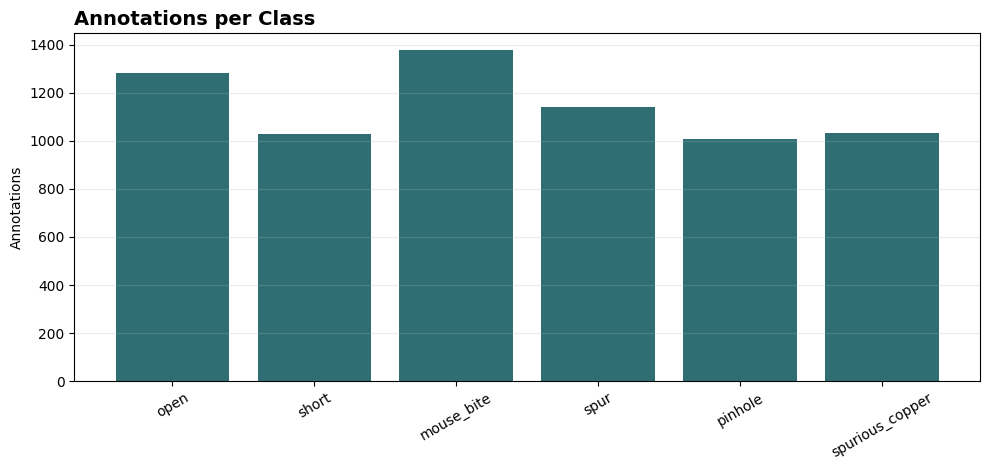

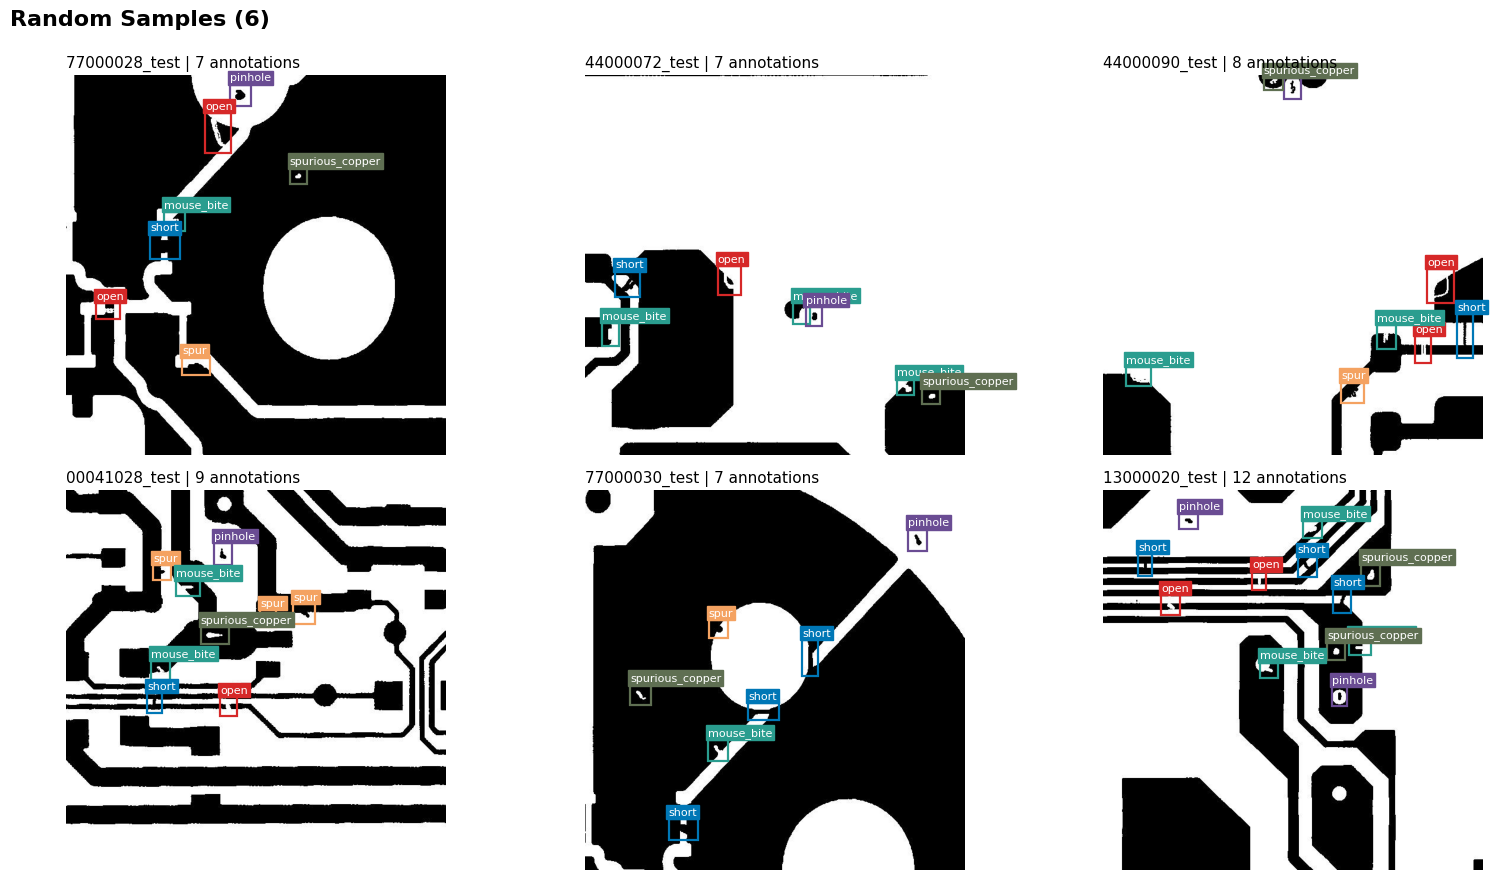

========== Inspect test.txt ==========
DeepPCB dataset inspection
Files: 500
Configured classes: 6
Classes present in annotations: 6
Empty images: 0
Total defect boxes: 3,140
Defect boxes per image: min 2, mean 6.28, max 13


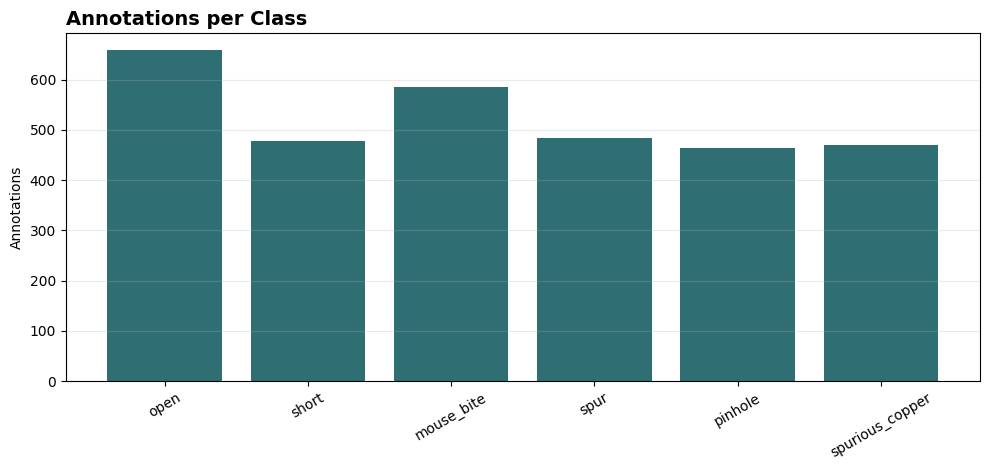

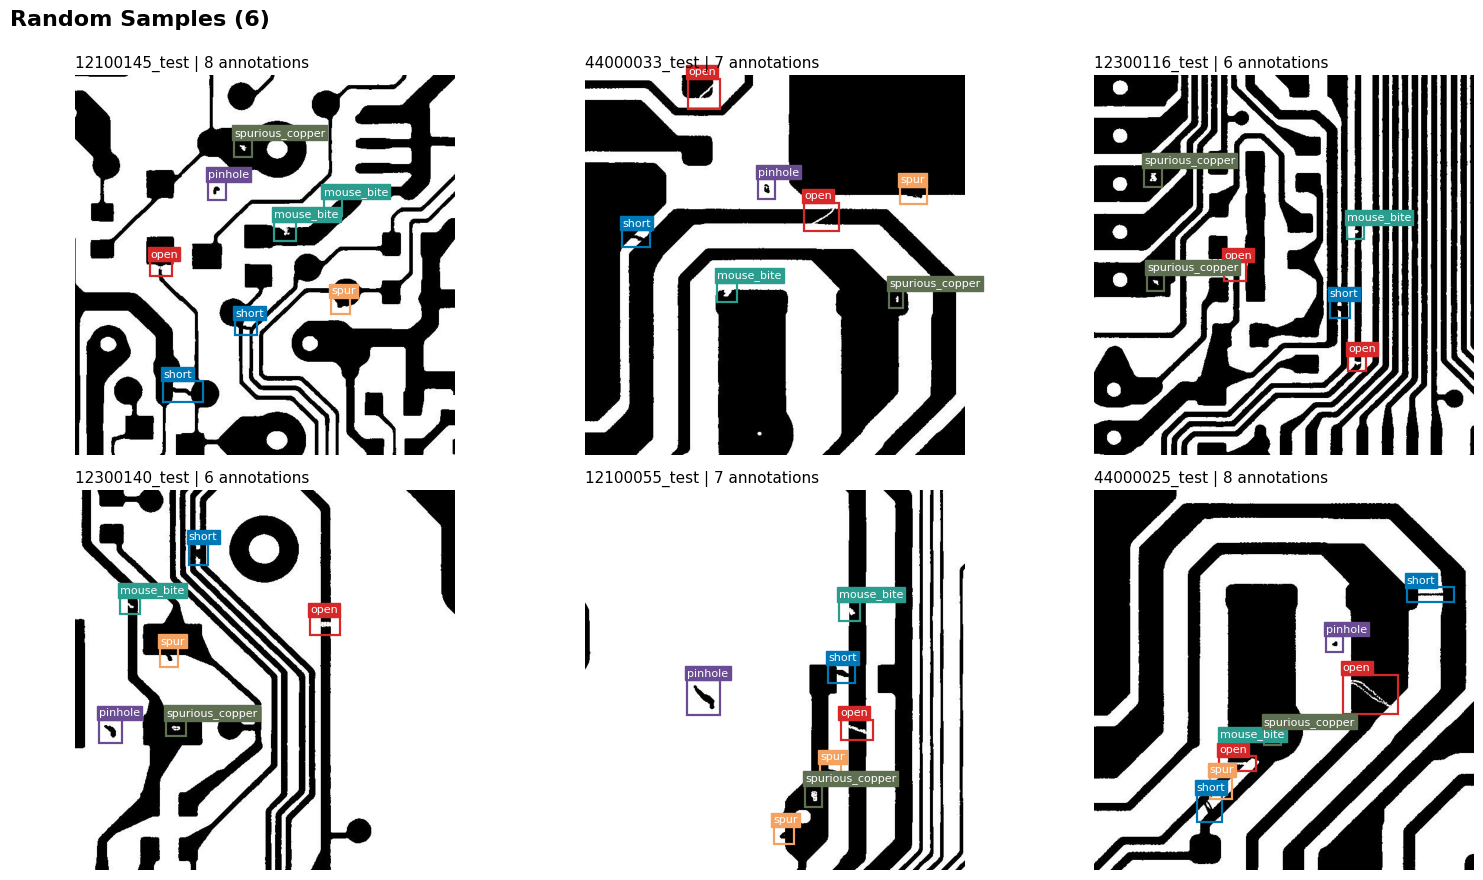

In [1]:
from notebooks.util import resolve_root
from neuro.config import load_yaml, NeuroTrainConfig, NeuroConfig
from neuro.prepare_dataset import PCBDataset

resolve_root()

train_config = load_yaml("neuro_train.yaml", NeuroTrainConfig)
model_config = load_yaml("neuro.yaml", NeuroConfig)

train_dataset = PCBDataset(train_config, "trainval.txt")
train_dataset.inspect()

test_dataset = PCBDataset(train_config, "test.txt")
test_dataset.inspect()

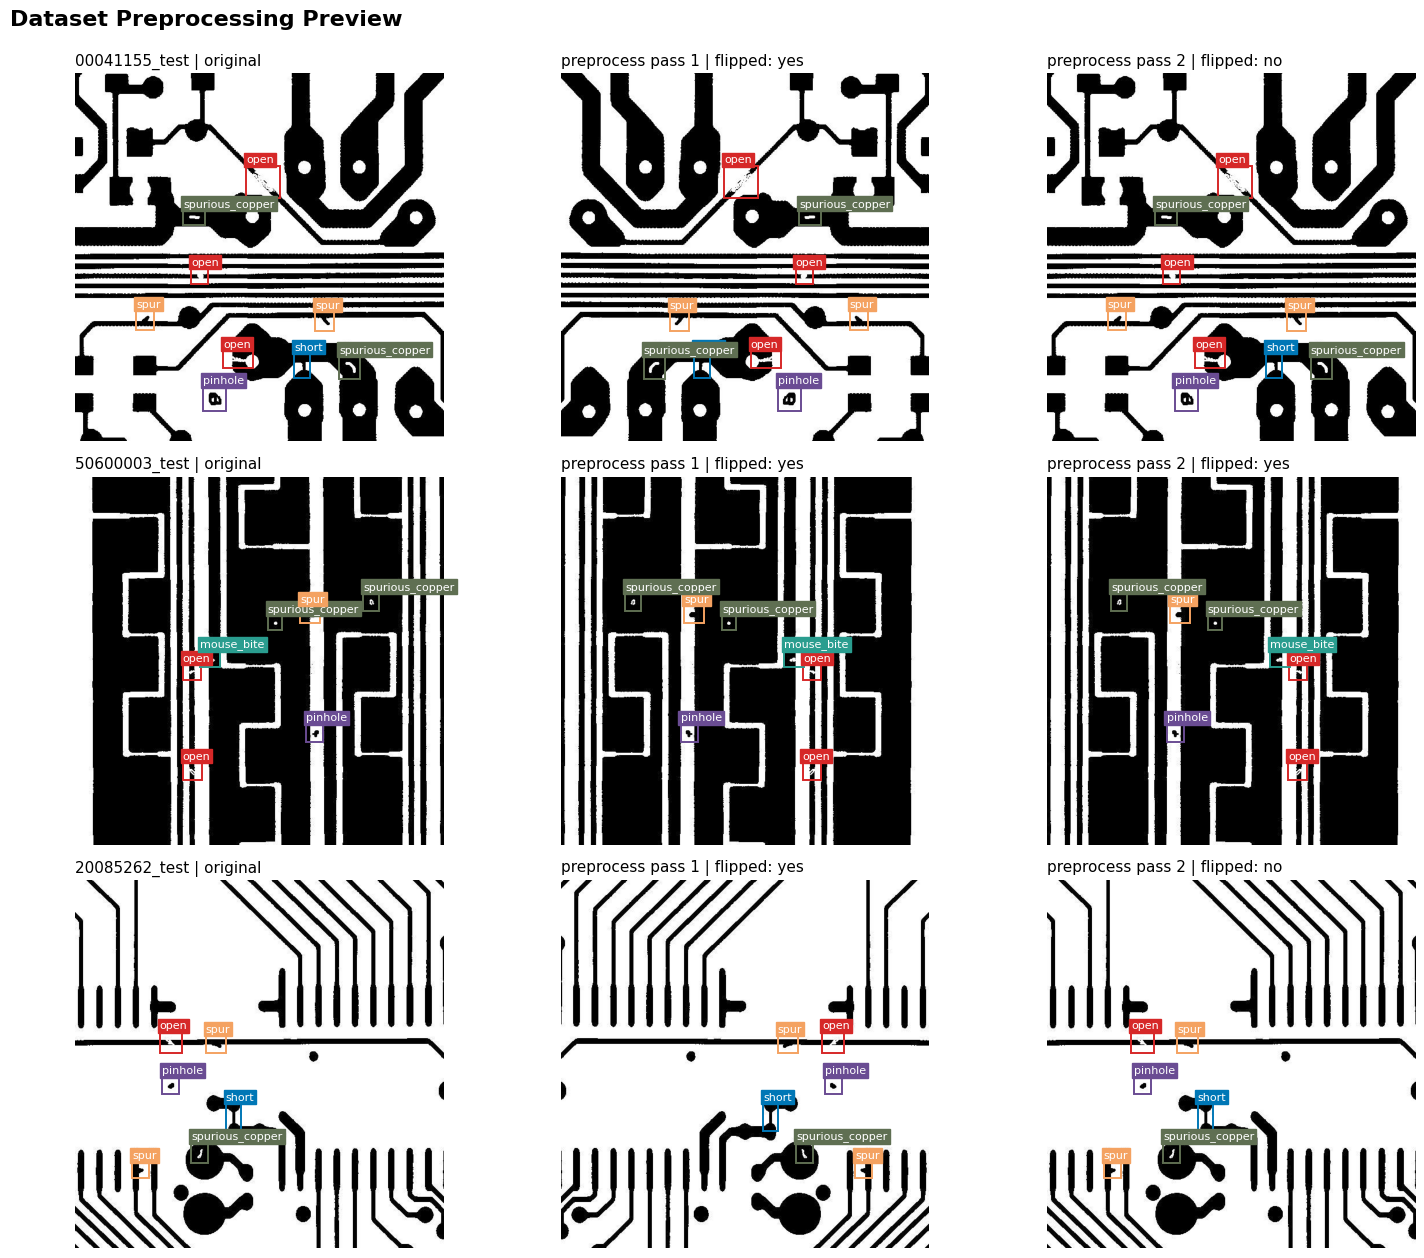

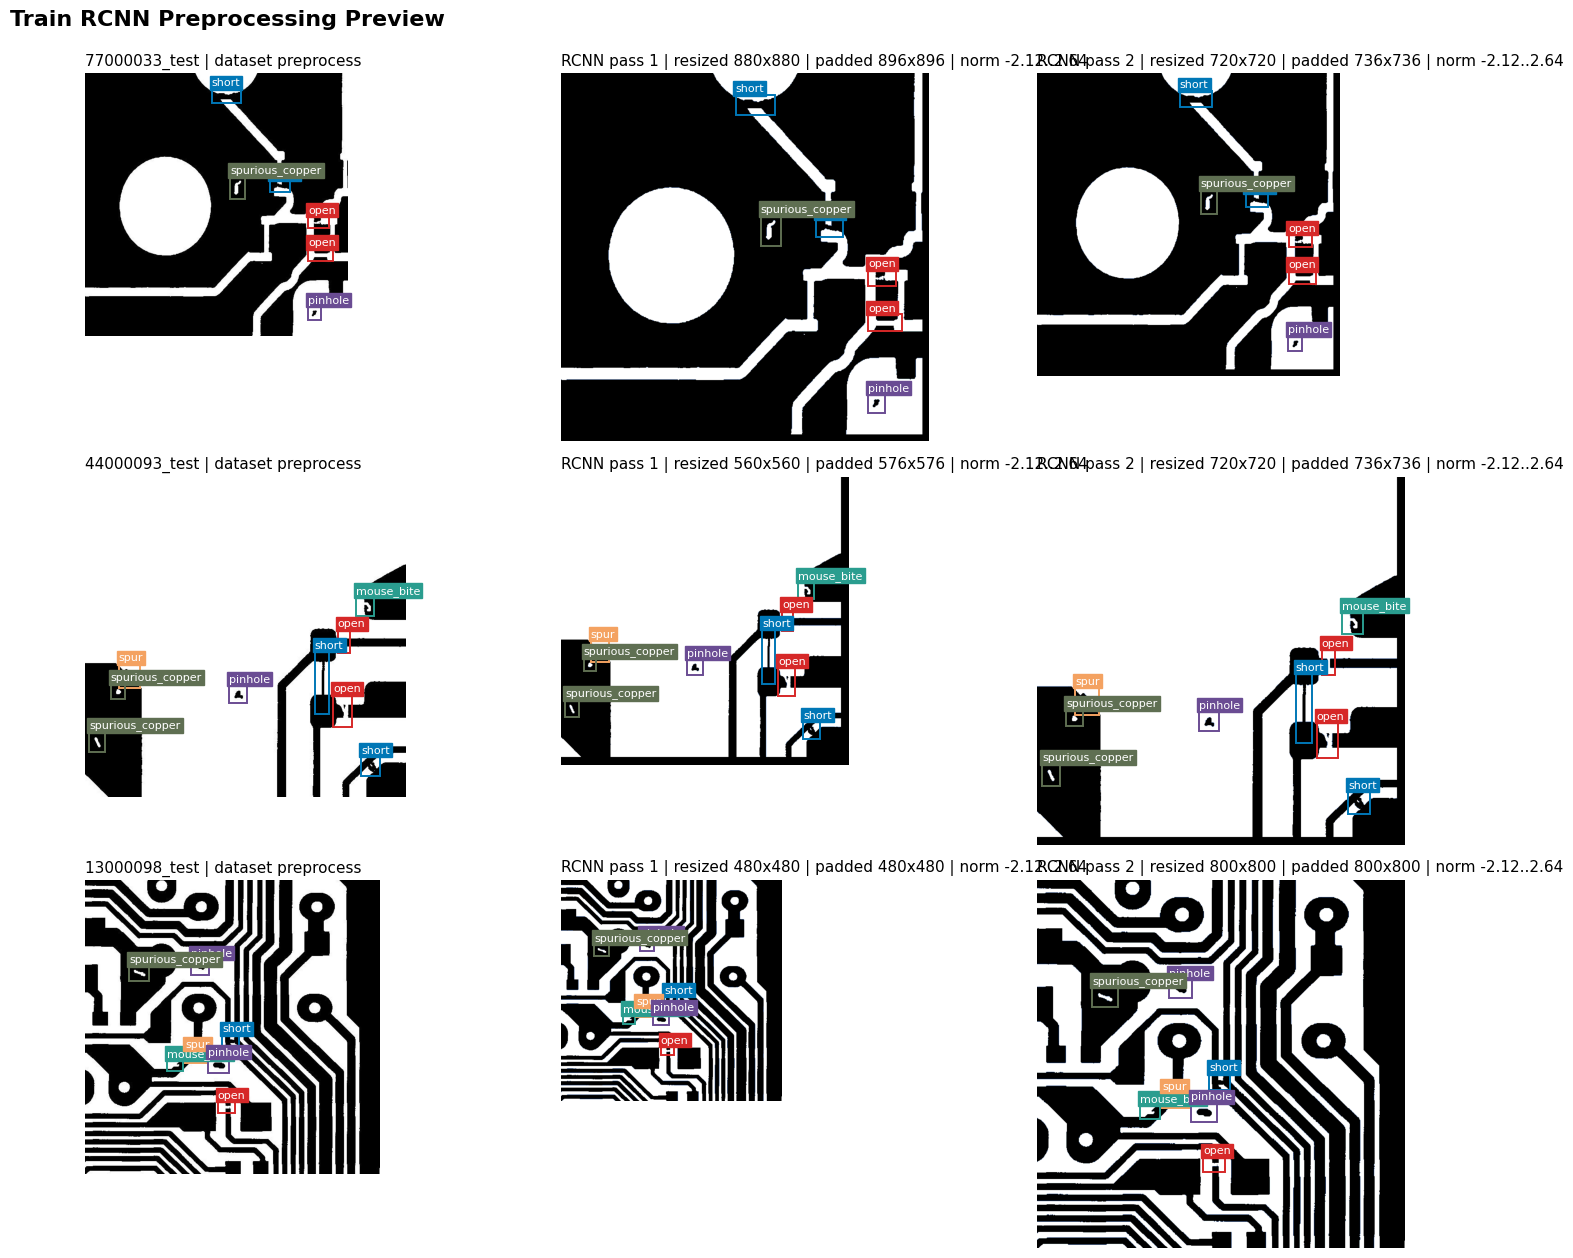

In [2]:
from neuro.preprocess_dataset import visualize_preprocessing, visualize_train_rcnn_preprocessing, test_preprocess, train_preprocess, RCNNPreprocessing

train_dataset.add_preprocess(train_preprocess())
test_dataset.add_preprocess(test_preprocess())
rcnn_preprocess = RCNNPreprocessing(train_config)

visualize_preprocessing(train_dataset)
visualize_train_rcnn_preprocessing(rcnn_preprocess, train_dataset)

In [ ]:
history_frame = pd.DataFrame(run_result["history"])
history_frame

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_frame.plot(x="epoch", y="loss_total", marker="o", ax=axes[0], legend=False)
axes[0].set_title("Total Training Loss")
axes[0].set_ylabel("loss")

history_frame.plot(
    x="epoch",
    y=[
        column
        for column in [
            "loss_classifier",
            "loss_box_reg",
            "loss_objectness",
            "loss_rpn_box_reg",
        ]
        if column in history_frame
    ],
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Detector Loss Breakdown")
axes[1].set_ylabel("loss")
plt.tight_layout()

In [ ]:
assert Path(run_result["checkpoint_path"]).exists()
assert Path(run_result["metrics_path"]).exists()
assert Path(run_result["history_path"]).exists()
run_result